In [1]:
import os
import copy
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import albumentations as A
import torch.nn.functional as F

import cv2
import torch
import torch.nn as nn

from tqdm import tqdm
from torch.utils.data import DataLoader
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor
from PIL import Image
from torch.utils.tensorboard import SummaryWriter
from sklearn.decomposition import PCA

import my_utils

from mae_models import MaskedAutoencoderViT, mae_vit_base_patch16_dec512d8b
import mae_models

In [18]:
model = torch.load(r'weights\MAE ViT\last.pth', weights_only=False)

In [33]:
x = torch.rand([2, 1, 224, 224]).cuda()

feature_maps = []
x = model.patch_embed(x)
for idx, block in enumerate(model.blocks):
    x = block(x)
    if idx in [7, 15, 23]:
        feature_maps.append(torch.einsum('nhwc->nchw', x.view(2, 14, 14, 1024)))
x = model.norm(x)

In [35]:
torch.concat(feature_maps, dim = 1).shape

torch.Size([2, 3072, 14, 14])

In [2]:
label_path = r'core_dataset\masks'
srez_path = r'core_dataset\images'

In [3]:
datasets = ['Beton',
            'data3d',
            'DRP421Bentheimer',
            'DRP421Leopard'
            ]

train_files = []
val_files = []
for dataset in datasets:
    dataset_files = [
        f for f in os.listdir(label_path)
        if f.startswith(dataset)
    ]


    train_files.extend(dataset_files[:128])
    val_files.extend(dataset_files[128:168])


train_image = []
train_target = []

for fname in train_files:
    label = cv2.imread(os.path.join(label_path, fname))
    srez = cv2.imread(os.path.join(srez_path, fname))

    train_image.append(srez[:, :, 0])
    train_target.append(label[:, :, 0])


val_image = []
val_target = []

for fname in val_files:
    label = cv2.imread(os.path.join(label_path, fname))
    srez = cv2.imread(os.path.join(srez_path, fname))

    val_image.append(srez[:, :, 0])
    val_target.append(label[:, :, 0])

In [4]:
transform = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Normalize(),
], additional_targets={'target': 'mask'})
val_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(),
], additional_targets={'target': 'mask'})

In [5]:
def prepare_model(chkpt_dir, arch='mae_vit_base_patch16'):
    # build model
    model = getattr(mae_models, arch)()
    # load model
    checkpoint = torch.load(chkpt_dir, map_location='cpu')
    msg = model.load_state_dict(checkpoint['model'], strict=False)
    print(msg)
    return model

# model_mae = prepare_model('mae_visualize_vit_base.pth', 'mae_vit_base_patch16')
H = W = 224
patch_size = 16
embed_dim = 1024
model_mae = mae_models.MaskedAutoencoderViT(img_size = H, in_chans = 1, patch_size = patch_size, embed_dim = embed_dim)
decoder = my_utils.Decoder(in_channels = embed_dim, num_classes = 1, upscale_factor = 16)

total = sum(p.numel() for p in model_mae.parameters())
trainable = sum(p.numel() for p in model_mae.parameters() if p.requires_grad)
print("ViT model")
print(f"Total params: {total:,}")
print(f"Trainable params: {trainable:,}")

total = sum(p.numel() for p in decoder.parameters())
trainable = sum(p.numel() for p in decoder.parameters() if p.requires_grad)
print("Decoder")
print(f"Total params: {total:,}")
print(f"Trainable params: {trainable:,}")

ViT model
Total params: 328,754,944
Trainable params: 328,452,352
Decoder
Total params: 11,014,785
Trainable params: 11,014,785


In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
batch_size = 8
num_epochs = 100
learning_rate = 1e-3
val_epochs = 5
mask_ratio = 0.5

optimizer = torch.optim.AdamW(
        model_mae.parameters(),
        lr=learning_rate
    )

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',         
    factor=0.2,    
    patience=3,            
    min_lr=1e-8,
    threshold = 1e-5          
)

In [7]:
validation_dataset = my_utils.CoreDataset(val_target, val_image, val_transform, multiply_channels = False)
train_dataset = my_utils.CoreDataset(train_target, train_image, transform, multiply_channels = False)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)

In [8]:
model_mae.cuda()
decoder.cuda()

log_dir = f"runs4/ViT {mask_ratio} {datetime.now().strftime('%d_%m %H_%M')}"
writer = SummaryWriter(log_dir=log_dir)

pos_weight = torch.tensor([9.0]).to(device)  # ~ (1-p)/p
val_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
dice_loss = my_utils.DiceLoss()  


scaler = torch.amp.GradScaler(device ,enabled=True)


for epoch in range(num_epochs):
    optimizer.zero_grad()
    model_mae.train()
    train_loss = 0
    
    for idx, batch in tqdm(enumerate(train_loader)):
        img, label = batch
        images = batch["image"].to(device).unsqueeze(1)   # [B, С, H, W]
        targets = batch["target"].to(device) # [B, H, W]

        with torch.autocast(device_type=device, dtype=torch.float16, enabled=True):
            loss, pred, mask = model_mae(images, mask_ratio=mask_ratio)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()

        showable = model_mae.unpatchify(pred)

        showable = torch.einsum('nchw->nhwc', showable)

        showable = showable.cpu().detach()
        showable += torch.abs(showable.min())
        showable /= torch.abs(showable.max())

        if not idx:
            # inputs_fig = my_utils.show_4_images(masked_images[:, 0, :, :])
            outputs_fig = my_utils.show_4_images(showable)

        train_loss += loss.item() / batch_size
        
            
    train_loss /= len(train_loader)
    
    #Дичайшая валидация
    model_mae.eval()
    decoder.reset()

    val_optim = torch.optim.AdamW(decoder.parameters(), lr = 1e-3)

    #тренируем сегментационную голову 
    # total_batches = val_epochs * len(train_loader)
    # with tqdm(total=total_batches, desc='Validation Train', unit='batch') as pbar:
    #     for _ in range(val_epochs):
    #         for batch in train_loader:
    #             images = batch["image"].to(device).unsqueeze(1)   # [B, С, H, W]
    #             targets = batch["target"].to(device) # [B, H, W]
    #             with torch.no_grad():
    #                 encoded = model_mae.forward_encoder(images, 0)[0][:, 1:, :].reshape(batch_size, H // patch_size, W // patch_size, embed_dim).permute(0, 3, 1, 2)

    #             segmented = decoder(encoded)
                
    #             loss = val_criterion(segmented.squeeze(), targets) + dice_loss(segmented, targets)

    #             loss.backward()

    #             val_optim.step()
    #             val_optim.zero_grad()

    #             pbar.update(1)

    val_cosmetic_loss = 0
    IoU = 0 


    for batch in tqdm(validation_loader):
        images = batch["image"].to(device).unsqueeze(1)   # [B, С, H, W]
        targets = batch["target"].to(device) # [B, H, W]
        
        with torch.no_grad():
            with torch.autocast(device_type=device, dtype=torch.float16, enabled=True):
                encoded = model_mae.forward_encoder(images, 0)[0][:, 1:, :].reshape(batch_size, H // patch_size, W // patch_size, embed_dim).permute(0, 3, 1, 2)
                cosmetic_loss, _, _ = model_mae(images, mask_ratio=mask_ratio)
            # segmented = decoder(encoded)
        
        val_cosmetic_loss += cosmetic_loss / batch_size

        # IoU += my_utils.compute_miou(segmented, targets, num_classes = 1)

    # segmented_target = my_utils.show_4_images(targets.detach().cpu())
    # segmented_fig = my_utils.show_4_images(segmented.squeeze().detach().cpu())
    
    
    # IoU /= len(validation_loader)
    val_cosmetic_loss /= len(validation_loader)


    print(f'Epoch {epoch}')
    print(f'Train loss {train_loss:.6f}')
    print(f'Validation loss {val_cosmetic_loss:.6f}')
    # print(f'Validation IoU {IoU:.4f}')
    writer.add_scalar('Loss/Train', train_loss, epoch)
    writer.add_scalar('Loss/Validation', val_cosmetic_loss, epoch)
    # writer.add_scalar('IoU', IoU, epoch)
    #writer.add_figure('Input', inputs_fig, epoch)
    writer.add_figure('Output/restored', outputs_fig, epoch)
    # writer.add_figure('Output/segment_targets', segmented_target, epoch)
    # writer.add_figure('Output/segment_preds', segmented_fig, epoch)
    plt.close()

    scheduler.step(train_loss)

torch.save(model_mae, "weights/MAE ViT/last.pth")
    

64it [00:16,  3.91it/s]
100%|██████████| 20/20 [00:01<00:00, 10.35it/s]


Epoch 0
Train loss 0.138552
Validation loss 0.129221


64it [00:15,  4.22it/s]
100%|██████████| 20/20 [00:01<00:00, 10.36it/s]


Epoch 1
Train loss 0.122649
Validation loss 0.121870


64it [00:15,  4.13it/s]
100%|██████████| 20/20 [00:02<00:00,  9.84it/s]


...

Epoch 97
Train loss 0.102216
Validation loss 0.104869


64it [00:15,  4.14it/s]
100%|██████████| 20/20 [00:01<00:00, 10.16it/s]


Epoch 98
Train loss 0.101872
Validation loss 0.105761


64it [00:15,  4.15it/s]
100%|██████████| 20/20 [00:01<00:00, 10.18it/s]


Epoch 99
Train loss 0.100959
Validation loss 0.104802


In [9]:
mask.shape

torch.Size([8, 196])

In [10]:
targets.shape

torch.Size([8, 224, 224])

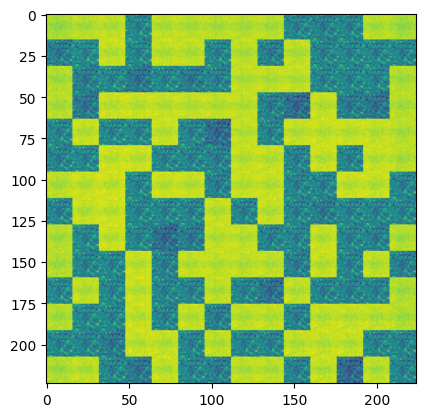

In [11]:
img = showable[0].cpu().detach()
img += torch.abs(img.min())
img /= torch.abs(img.max())
plt.imshow(img)

In [12]:
F.normalize(images, dim = 0).mean()

tensor(0.2009, device='cuda:0')

In [13]:
img.max()

tensor(1., dtype=torch.float16)

In [14]:
showable.shape

torch.Size([8, 224, 224, 1])